<a href="https://colab.research.google.com/github/PrachitaJadhav/DiabetesPrediction-/blob/main/Coffee_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

         date                 datetime cash_type                 card  money  \
0  2024-03-01  2024-03-01 10:15:50.520      card  ANON-0000-0000-0001   38.7   
1  2024-03-01  2024-03-01 12:19:22.539      card  ANON-0000-0000-0002   38.7   
2  2024-03-01  2024-03-01 12:20:18.089      card  ANON-0000-0000-0002   38.7   
3  2024-03-01  2024-03-01 13:46:33.006      card  ANON-0000-0000-0003   28.9   
4  2024-03-01  2024-03-01 13:48:14.626      card  ANON-0000-0000-0004   38.7   

     coffee_name  
0          Latte  
1  Hot Chocolate  
2  Hot Chocolate  
3      Americano  
4          Latte  
date            0
datetime        0
cash_type       0
card           89
money           0
coffee_name     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1133 entries, 0 to 1132
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         1133 non-null   datetime64[ns]
 1   datetime     1133 non-null

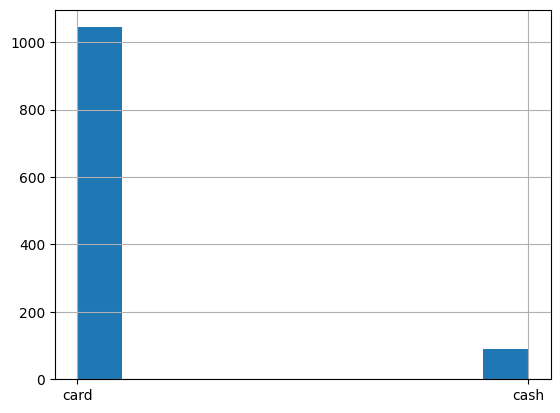

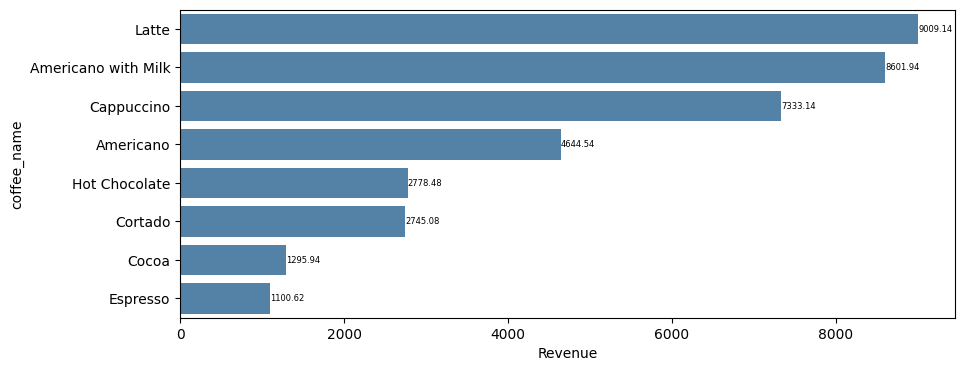

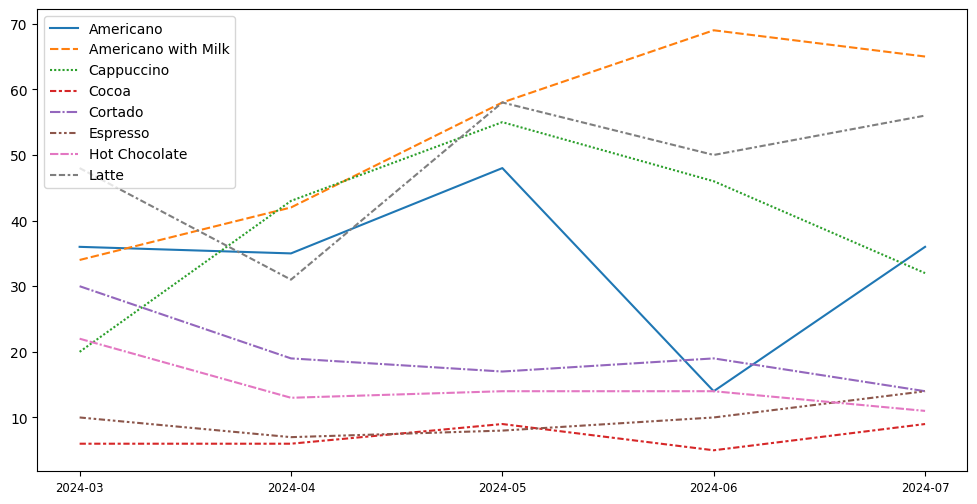

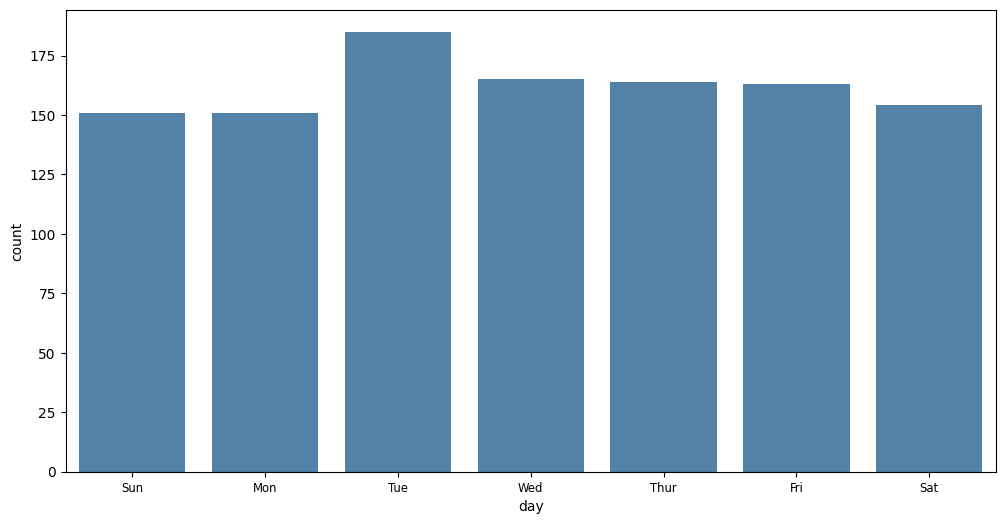

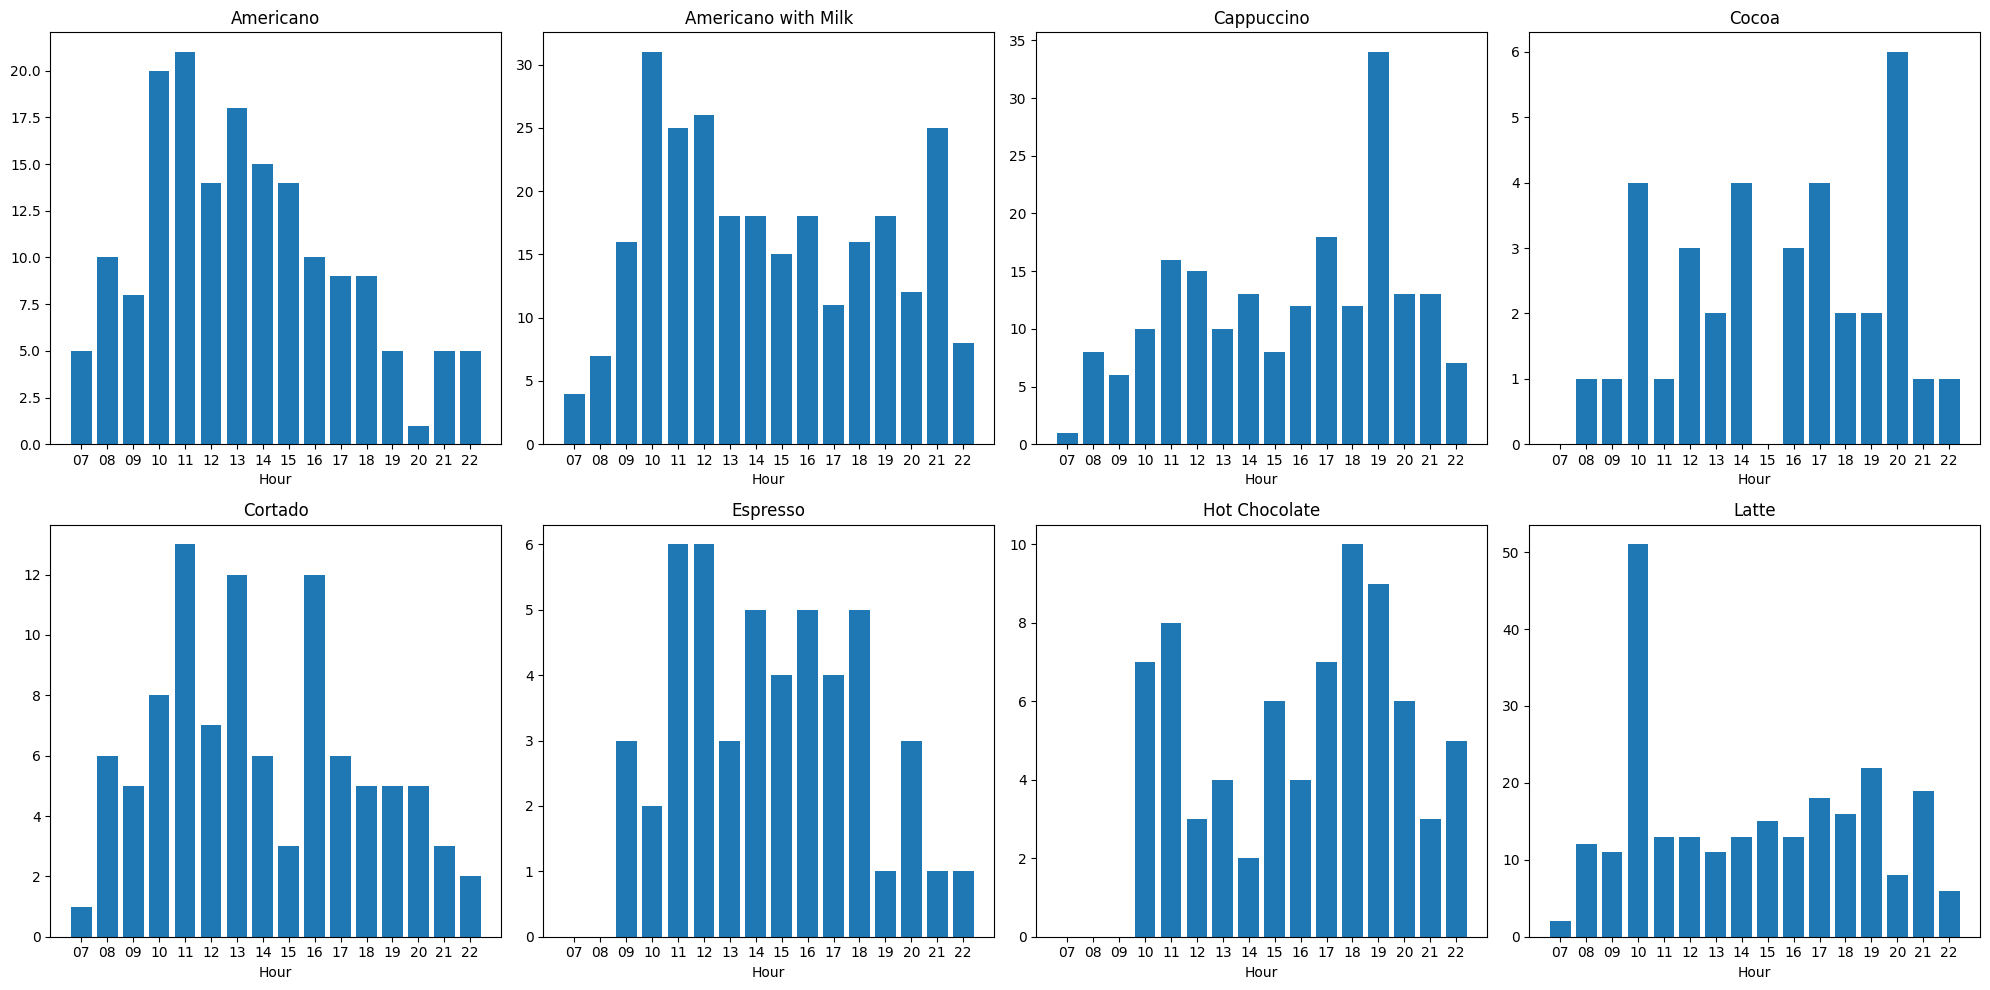

In [34]:
import pandas as pd
from scipy.stats import zscore
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# Load the dataset
data = pd.read_csv('/content/index.csv')
print(data.head())

# Check for missing values
print(data.isnull().sum())

data.duplicated().sum()

data.describe().T
data.loc[:,['cash_type','card','coffee_name']].describe().T

data[data['card'].isnull()]['cash_type'].value_counts()
data['cash_type'].hist()
data['cash_type'].value_counts(normalize=True)

pd.DataFrame(data['coffee_name'].value_counts(normalize=True).sort_values(ascending=False).round(4)*100)

data['date']=pd.to_datetime(data['date'])
data['datetime']=pd.to_datetime(data['datetime'])
#Create column of Month, Weekdays, and Hours
data['month']=data['date'].dt.strftime('%Y-%m')
data['day']=data['date'].dt.strftime('%w')
data['hour']=data['datetime'].dt.strftime('%H')

data.info()
data.head()
[data['date'].min(),data['date'].max()]

revenue_data =data.groupby(['coffee_name']).sum(['money']).reset_index().sort_values(by='money',ascending=False)
plt.figure(figsize=(10,4))
ax =sns.barplot(data=revenue_data,x='money',y='coffee_name',color='steelblue')
ax.bar_label(ax.containers[0], fontsize=6)
plt.xlabel('Revenue')

monthly_sales =data.groupby(['coffee_name','month']).count()['date'].reset_index().rename(columns={'date':'count'}).pivot(index='month',columns='coffee_name',values='count').reset_index()

monthly_sales.describe().T.loc[:,['min','max']]
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_sales)
plt.legend(loc='upper left')
plt.xticks(range(len(monthly_sales['month'])),monthly_sales['month'],size='small')

weekday_sales =data.groupby(['day']).count()['date'].reset_index().rename(columns={'date':'count'})

plt.figure(figsize=(12,6))
sns.barplot(data=weekday_sales,x='day',y='count',color='steelblue')
plt.xticks(range(len(weekday_sales['day'])),['Sun','Mon','Tue','Wed','Thur','Fri','Sat'],size='small')

daily_sales =data.groupby(['coffee_name','date']).count()['datetime'].reset_index().reset_index().rename(columns={'datetime':'count'}).pivot(index='date',columns='coffee_name',values='count').reset_index().fillna(0)
daily_sales.iloc[:,1:].describe().T.loc[:,['min','max']]
hourly_sales =data.groupby(['hour']).count()['date'].reset_index().rename(columns={'date':'count'})
sns.barplot(data=hourly_sales,x='hour',y='count',color='steelblue')

hourly_sales_by_coffee =data.groupby(['hour','coffee_name']).count()['date'].reset_index().rename(columns={'date':'count'}).pivot(index='hour',columns='coffee_name',values='count').fillna(0).reset_index()
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
# Flatten the array of subplots for easy iteration
axs = axs.flatten()
# Loop through each column in the DataFrame, skipping the 'Index' column
for i, column in enumerate(hourly_sales_by_coffee.columns[1:]):
    axs[i].bar(hourly_sales_by_coffee['hour'], hourly_sales_by_coffee[column])
    axs[i].set_title(f'{column}')
    axs[i].set_xlabel('Hour')
#axs[i].set_ylabel('Sales')
plt.tight_layout()
# Show the plot
plt.show()


Sample of the dataset:
         date                 datetime cash_type                 card  money  \
0  2024-03-01  2024-03-01 10:15:50.520      card  ANON-0000-0000-0001   38.7   
1  2024-03-01  2024-03-01 12:19:22.539      card  ANON-0000-0000-0002   38.7   
2  2024-03-01  2024-03-01 12:20:18.089      card  ANON-0000-0000-0002   38.7   
3  2024-03-01  2024-03-01 13:46:33.006      card  ANON-0000-0000-0003   28.9   
4  2024-03-01  2024-03-01 13:48:14.626      card  ANON-0000-0000-0004   38.7   

     coffee_name  
0          Latte  
1  Hot Chocolate  
2  Hot Chocolate  
3      Americano  
4          Latte  

Missing values per column:
date            0
datetime        0
cash_type       0
card           89
money           0
coffee_name     0
dtype: int64

Total duplicated rows: 0


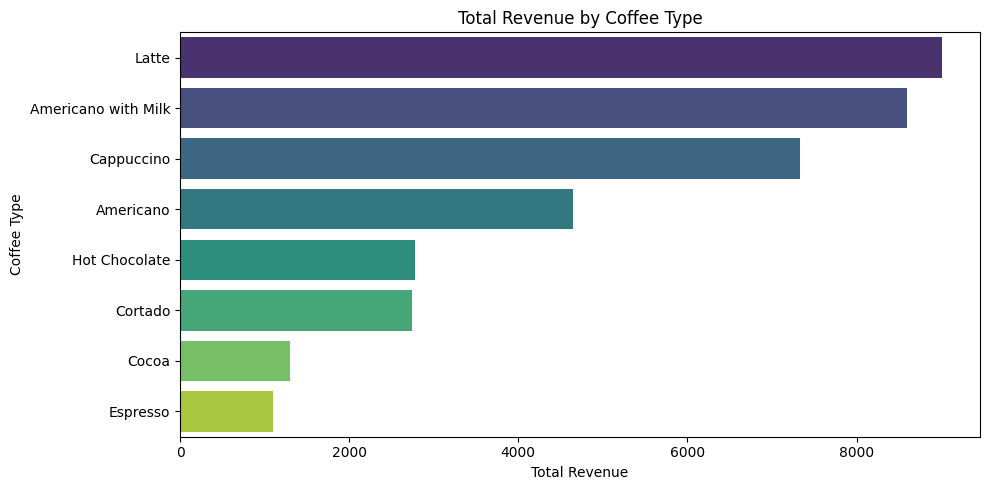

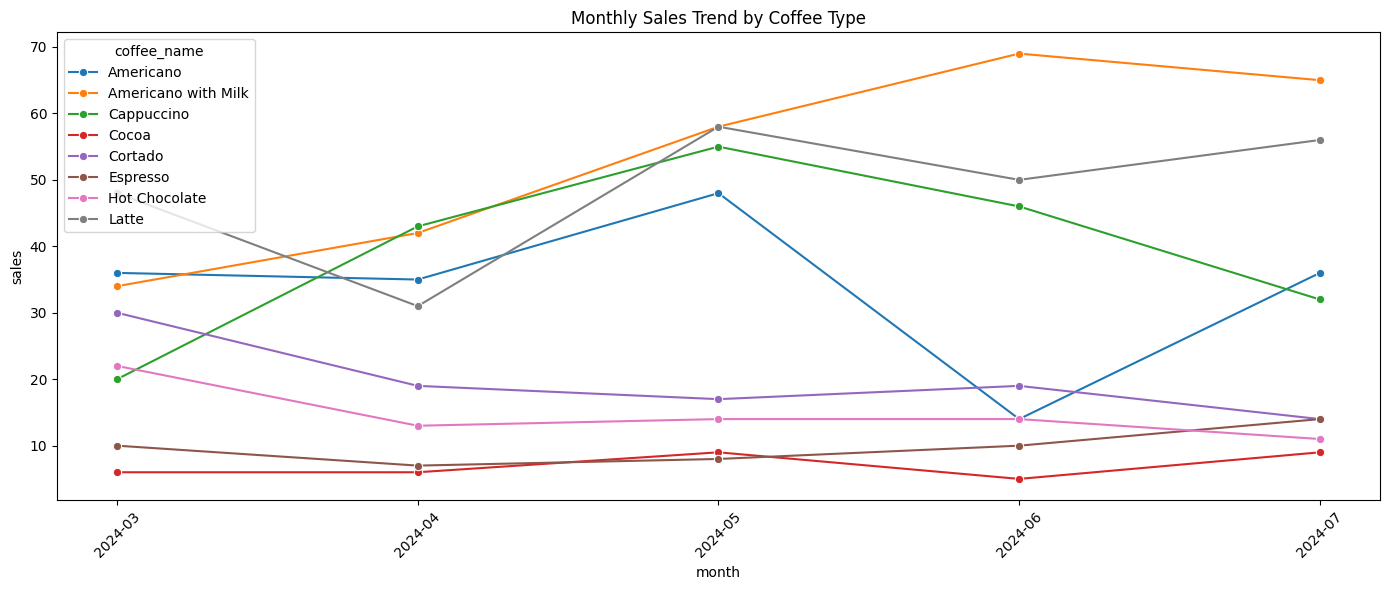

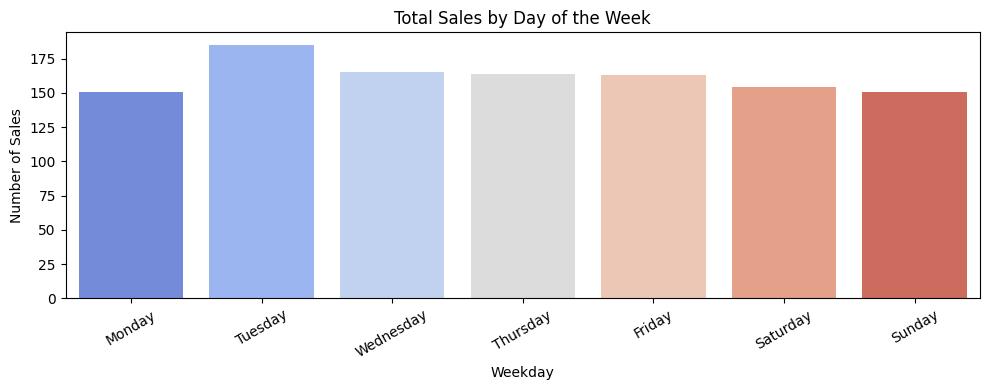

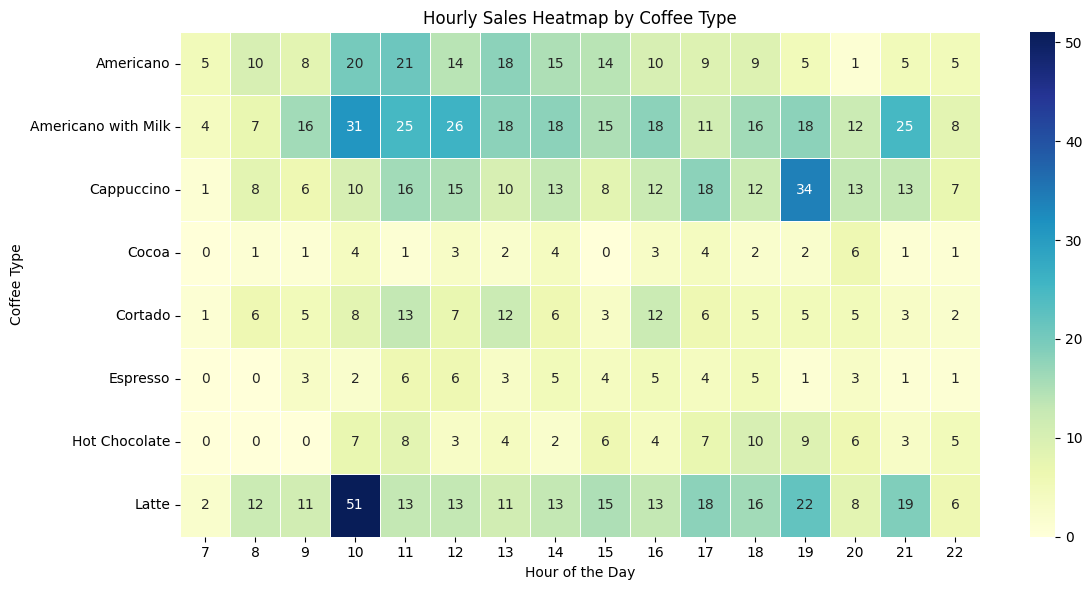

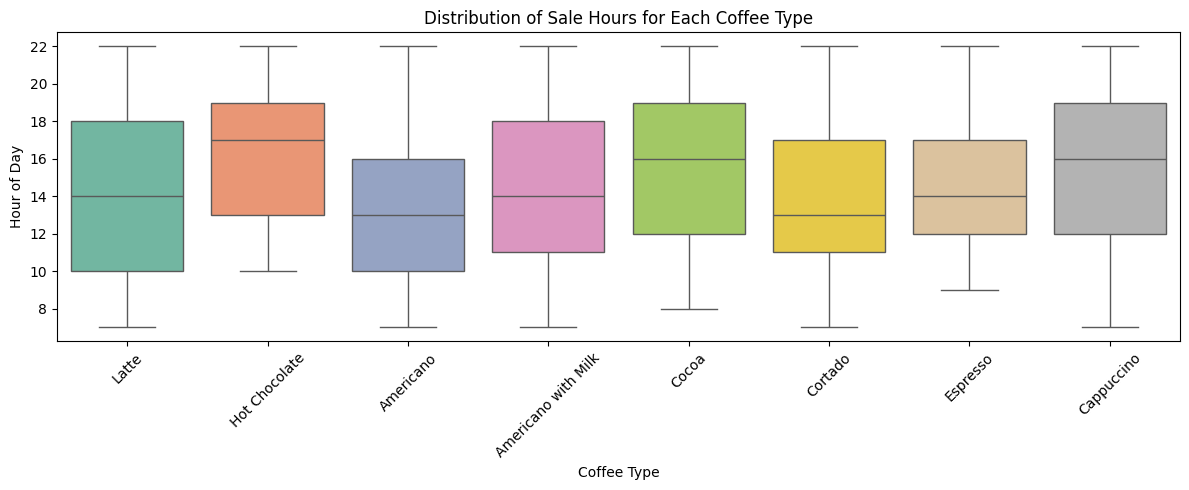

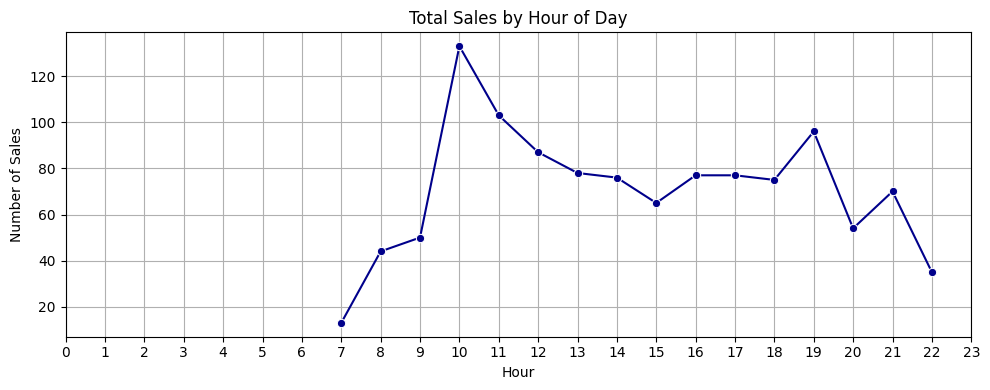

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load and preview the dataset
data = pd.read_csv('/content/index.csv')
print("Sample of the dataset:")
print(data.head())

# Check for missing and duplicate values
print("\nMissing values per column:")
print(data.isnull().sum())
print(f"\nTotal duplicated rows: {data.duplicated().sum()}")

# Convert date columns to datetime
data['date'] = pd.to_datetime(data['date'])
data['datetime'] = pd.to_datetime(data['datetime'])

# Feature engineering: extract time-based features
data['month'] = data['date'].dt.to_period('M')
data['weekday'] = data['date'].dt.day_name()
data['hour'] = data['datetime'].dt.hour

# --- Revenue by Coffee Type ---
revenue_summary = data.groupby('coffee_name')['money'].sum().reset_index().sort_values(by='money', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(data=revenue_summary, x='money', y='coffee_name', hue='coffee_name', palette='viridis', legend=False)
plt.title("Total Revenue by Coffee Type")
plt.xlabel("Total Revenue")
plt.ylabel("Coffee Type")
plt.tight_layout()
plt.show()



# --- Monthly Sales Trend ---
# Monthly Sales Trend (Fix: convert Period to string)
monthly_sales = data.groupby(['month', 'coffee_name']).size().reset_index(name='sales')
monthly_sales['month'] = monthly_sales['month'].astype(str)  # Fix the Period dtype issue

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_sales, x='month', y='sales', hue='coffee_name', marker='o')
plt.title("Monthly Sales Trend by Coffee Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# --- Weekly Sales Volume ---
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_sales = data['weekday'].value_counts().reindex(weekday_order)

# Convert to DataFrame for seaborn compatibility
weekday_sales_df = pd.DataFrame({
    'weekday': weekday_sales.index,
    'sales': weekday_sales.values
})

plt.figure(figsize=(10, 4))
sns.barplot(data=weekday_sales_df, x='weekday', y='sales', hue='weekday', palette='coolwarm', legend=False)
plt.title("Total Sales by Day of the Week")
plt.ylabel("Number of Sales")
plt.xlabel("Weekday")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# --- Hourly Sales Heatmap ---
hourly_coffee_sales = data.groupby(['hour', 'coffee_name']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(hourly_coffee_sales.T, cmap='YlGnBu', linewidths=0.5, annot=True, fmt='d')
plt.title("Hourly Sales Heatmap by Coffee Type")
plt.xlabel("Hour of the Day")
plt.ylabel("Coffee Type")
plt.tight_layout()
plt.show()

# Convert hour to numeric
data['hour'] = data['hour'].astype(int)

plt.figure(figsize=(12, 5))
sns.boxplot(data=data, x='coffee_name', y='hour', hue='coffee_name', palette='Set2', legend=False)
plt.title("Distribution of Sale Hours for Each Coffee Type")
plt.ylabel("Hour of Day")
plt.xlabel("Coffee Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# --- Total Hourly Sales Line Plot ---
hourly_sales_total = data.groupby('hour').size().reset_index(name='count')

plt.figure(figsize=(10, 4))
sns.lineplot(data=hourly_sales_total, x='hour', y='count', marker='o', color='darkblue')
plt.title("Total Sales by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Sales")
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()
